In [ ]:
%%HTML
<script src="require.js"></script>

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from sklearn.metrics.pairwise import cosine_similarity
from functools import reduce
import glob
from IPython.display import HTML, display, Markdown, Image

In [3]:
HTML(
    '<script src="https://cdnjs.cloudflare.com/ajax/libs/jquery/2.0.3/'
    'jquery.min.js"></script>'
    '<script>'
    'code_show=true;'
    'function code_toggle(){'
    'if(code_show){'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').hide();"
    '}else{'
    "$('div.jp-CodeCell > div.jp-Cell-inputWrapper').show();"
    '}'
    'code_show=!code_show;'
    '}'
    '$(document).ready(code_toggle);'
    '</script>'
    '<form action="javascript:code_toggle()">'
    '<input type="submit" value="Click here to toggle on/off the raw code.">'
    '</form>'
)

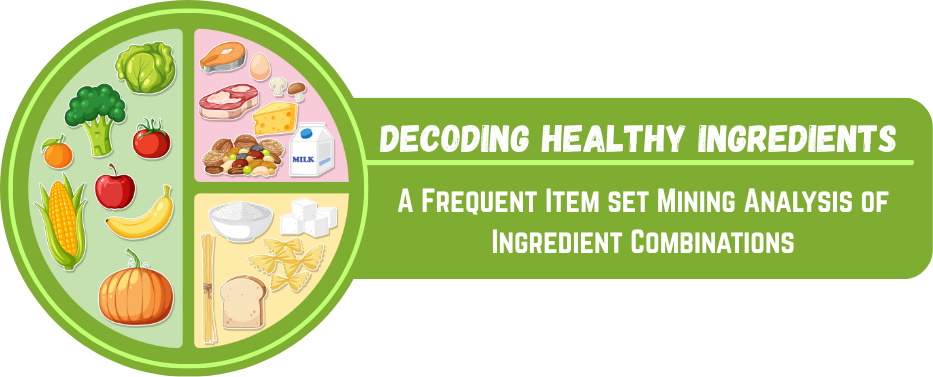

<a id='ExecSum'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">
I. Abstract
</h1>


<a id='Introduction'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">II. Introduction</h1>

Maritime traffic in U.S. waters is continuously monitored to ensure safe and efficient navigation, with authorities relying on detailed information about vessel positions, speeds, and cargo types. The National Oceanic and Atmospheric Administration (NOAA) collects this data through the Automatic Identification System (AIS), providing real-time records of vessel movements. However, even with AIS monitoring, busy waterways remain prone to accidents, as illustrated by the May 2025 collision of the Mexican navy tall ship ARM Cuauhtémoc with the Brooklyn Bridge, which caused two deaths and 19 injuries (Associated Press, 2025). In addition, the March 2024 incident in which the container ship MV Dali collided with the Francis Scott Key Bridge in Baltimore led to a major span collapse and six worker fatalities (Oladipo, 2024). These cases demonstrate how vessel speed, traffic density, maneuvering in constrained waterways, and cargo types can all contribute to elevated risk.

These cases illustrate why analyzing vessel activity patterns is important. By identifying peak vessel activity by time, dominant cargo or vessel types, and variations in speed under different traffic densities, authorities can better anticipate high-risk periods and issue advisories or optimize traffic management, thereby reducing the likelihood of collisions.

Thus, this raises the question: **How do peaks in vessel activity and variations in ship speed relate to cargo type and traffic density?** To answer the problem statement, the study analyzes 2023 NOAA AIS data by aggregating vessel records by:
1. Determining which cargo types dominate traffic by categorizing vessels, and
2. Identifying peaks in vessel activity by aggregating ship records by month and hour, and
3. Investigating how ship speeds vary under different traffic densities to understand the relationship between speed and congestion. 

These objectives aim to provide actionable insights for data-driven maritime traffic management and safety risk mitigation.


<a id='Methodology'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">III. METHODOLOGY</h1>

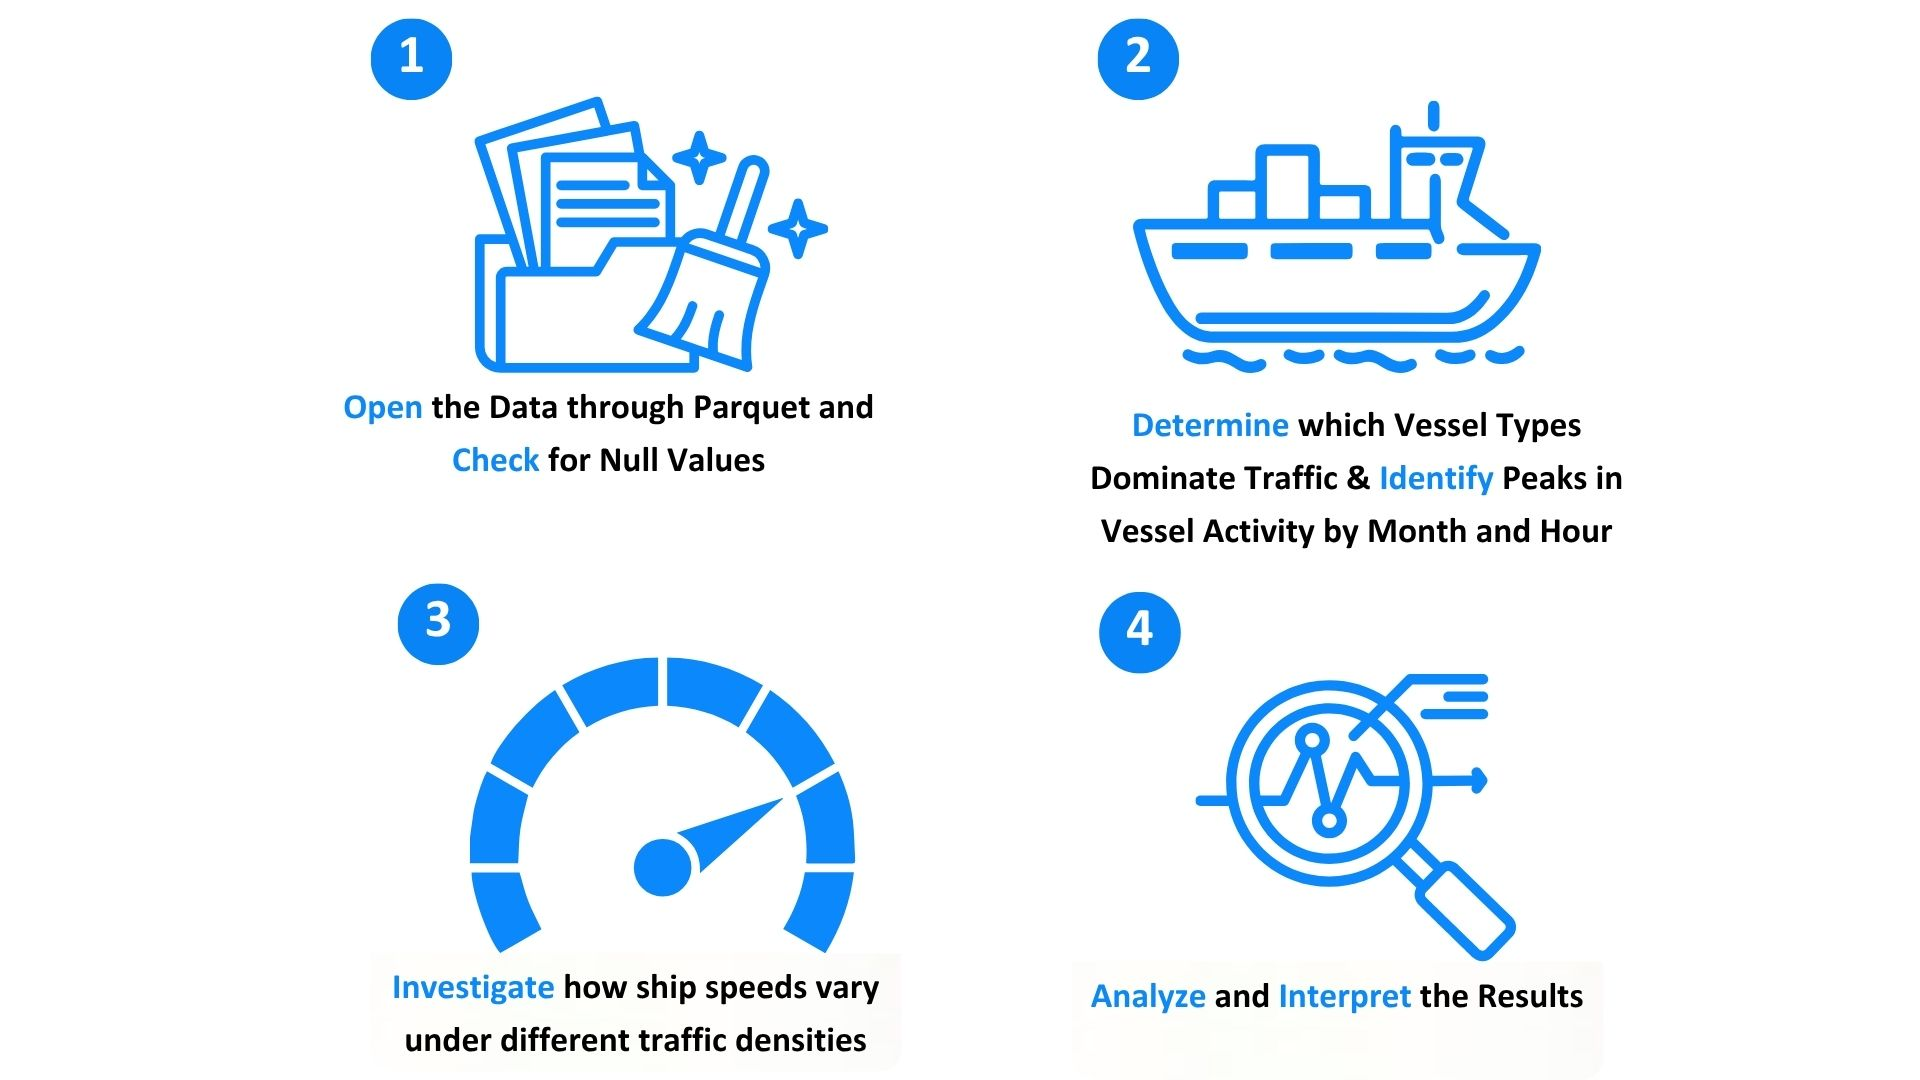
<left><span style="font-size:14px"><b>Figure 1. </b>Methodology</span></left>

*3.1 Open the Data through Parquet and Check for Null Values*

The 2023 NOAA AIS data, stored as Parquet files, is loaded into Spark DataFrames. Initial data exploration is performed to inspect the schema and identify any null or missing values in key columns such as `VesselType`, `SOG` (speed over ground), `LAT`, `LON`, `Month`, and `Hour`. 

*3.2 Determine which Vessel Types Dominate Traffic & Identify Peaks in Vessel Activity by Month and Hour*


The number of unique vessels is counted for each cargo type using Spark DataFrames. This step identifies the most frequently operating vessel categories. AIS records are aggregated by `Month` and `Hour` to determine when vessel traffic is heaviest. A stacked bar chart shows how each vessel type contributes to overall traffic and how these patterns change over time.

*3.3 Investigate how ship speeds vary under different traffic densities*

The number of nearby vessels for each ship is calculated using `LAT` and `LON` coordinates. To approximate proximity, a bounding box of ±0.05 degrees (roughly 5 km) was defined around each ship, and any vessels within that box were counted as nearby. Scatterplots are created comparing the number of nearby ships to the ship’s speed (`SOG`) per hour, examining whether ship speeds decrease in higher-density conditions or increase when traffic is lighter.

*3.4 Analyze and Interpret the Results*


Insights and business recommendations from the grouped bar charts and scatterplots are synthesized to interpret peak traffic periods, dominant vessel types, and speed behaviors under varying traffic densities.


<a id='Collection'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">IV. Open the Data through Parquet and Check for Null Values</h1>

The data collection section involves three key steps:
1. Identifying the data source;
2. Data Collection from Jojie; 
3. Data Description;
4. Check for Null Values; and
5. Preprocess the Data

<h2 style="color:#ff9a00">1. Identifying the data source</h2>

The NOAA AIS dataset, which is publicly available through the ‘jojie-collected’ repository in the /mnt/data/public directory maintained by the Asian institute of Management, was used in this study. Specifically, the dataset, located at `/mnt/data/public/noaa-ais`, contains information on AIS transmission records like ship locations, identifiers, movement logs, and vessel characteristics.

<h2 style="color:#ff9a00">2. Data Collection from Jojie</h2>

While the team retrieved the data using the Jojie public dataset repository, it is also important to recognize the original data source and its collection process. The NOAA AIS dataset is a publicly available collection of maritime Automatic Identification System (AIS) records gathered by the US National Oceanic and Atmospheric Administration. The dataset contains millions of ship position reports and vessel metadata. This includes navigational status, timestamps, vessel type, identifiers (MMSI), and more. For this project, two subsets of datasets were accessed in Parquet format, specifically:
- `2023_NOAA_AIS_logs_*.parquet`: contains ship movement logs
- `2023_NOAA_AIS_ships_*.parquet`: contains vessel reference information


These files were processed using PySpark for scalable cleaning, transformation, and modelling for the large volume of AIS data.


<h2 style="color:#ff9a00">3. Data Description</h2>

The AIS dataset consists of maritime transmission logs for 2023, split into monthly Parquet files, 12 movement (`logs`) files that is approximately 2.7B record and 12 metadata (`ships`) files with about 500k vessel records. For this analysis, only a group of navigational and vessel classification fields were focused on. This is shown in Table 1 below.


| **Feature**    | **Description**                                                                                                                              |
| -------------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| `MMSI`         | Maritime Mobile Service Identity, a unique identifier for each ship.                                                                         |
| `VesselType`   | Category representing the vessel class — cargo, fishing, tanker. Missing values were assigned `0` per AIS specifications when not available. |
| `LAT`          | Latitude coordinate provided during a ship’s AIS transmission.                                                                               |
| `LON`          | Longitude coordinate reported during a ship’s AIS transmission.                                                                              |
| `SOG`          | Speed of a vessel based on the Earth’s surface.                                                                                              |
| `BaseDateTime` | Original UTC timestamp of the AIS transmission (full date and time).                                                                         |


<h2 style="color:#ff9a00">4. Check for the Null Values </h2>

As shown in Tables 2 and 3, all selected features, with the exception of `VesselType`, were complete across all AIS log records. The missing values in `VesselType` accounted for only 4.91% of the data. Given the small proportion, no rows were removed. Instead, in accordance with AIS specifications, missing entries were assigned a placeholder value of `0` ("Not Available"). This approach preserved all records for subsequent analysis.

In [2]:
# Set the Spark Session
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")


# Read the files
logs_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_*.parquet")
ships_df = spark.read.parquet("/mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_*.parquet")
log_no_4_paths = sorted(
    p for p in glob.glob("/mnt/data/public/noaa-ais/2023_NOAA_AIS_logs_*.parquet")
    if "_04.parquet" not in p
)
ship_paths = sorted(
    glob.glob("/mnt/data/public/noaa-ais/2023_NOAA_AIS_ships_*.parquet")
)

logs_df1 = spark.read.parquet(*log_no_4_paths)
ships_df = spark.read.parquet(*ship_paths)

In [3]:
def compute_or_load_nulls(df, output_parquet):
    """
    Checks if the null counts Parquet exists.
    If yes, loads it. If not, computes null counts and saves to Parquet.
    Returns a Pandas DataFrame with null counts.
    """
    if os.path.exists(output_parquet):
        return spark.read.parquet(output_parquet).toPandas()
    
    cols = df.columns
    null_counts = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in cols
    ])
    
    # Save as Parquet
    null_counts.write.mode("overwrite").parquet(output_parquet)
    
    return null_counts.toPandas()

# Usage for logs
logs_nulls = compute_or_load_nulls(logs_df1, "data/logs_null_summary.parquet")

# Usage for ships
ships_nulls = compute_or_load_nulls(ships_df, "data/ships_null_summary.parquet")

In [4]:
# Total rows in each Spark DataFrame
total_rows_logs = logs_df1.count()
total_rows_ships = ships_df.count()

# Logs summary
logs_summary = (
    compute_or_load_nulls(log_no_4_paths, "data/logs_null_summary.parquet")
    .T.sum(axis=1)
    .reset_index()
)
logs_summary.columns = ["Attribute", "Number of Null Values"]
logs_summary["Percentage of Nulls (%)"] = (logs_summary["Number of Null Values"] / total_rows_logs * 100).round(2)

# Ships summary
ships_summary = (
    compute_or_load_nulls(ship_paths, "data/ships_null_summary.parquet")
    .T.sum(axis=1)
    .reset_index()
)
ships_summary.columns = ["Attribute", "Number of Null Values"]
ships_summary["Percentage of Nulls (%)"] = (ships_summary["Number of Null Values"] / total_rows_ships * 100).round(2)

# Display nicely
display(logs_summary)
display(Markdown("**Table 2.** Count of Null Values in AIS Log Parquet Files"))


display(ships_summary)
display(Markdown("**Table 3.** Count of Null Values in AIS Ship Parquet Files"))

,Attribute,Number of Null Values,Percentage of Nulls (%)
0,MMSI,0,0.0
1,BaseDateTime,0,0.0
2,LAT,0,0.0
3,LON,0,0.0
4,SOG,0,0.0
5,COG,0,0.0
6,Heading,0,0.0


**Table 2.** Count of Null Values in AIS Log Parquet Files

,Attribute,Number of Null Values,Percentage of Nulls (%)
0,MMSI,0,0.00
1,VesselName,0,0.00
2,IMO,0,0.00
3,CallSign,0,0.00
4,VesselType,25103,4.91
5,Status,314844,61.55
6,Length,56001,10.95
7,Width,107255,20.97
8,Draft,392080,76.65
9,Cargo,331664,64.84


**Table 3.** Count of Null Values in AIS Ship Parquet Files

<h2 style="color:#ff9a00">5. Preprocess the Data </h2>

The `BaseDateTime` column, originally stored as a numeric timestamp, was converted to a proper datetime format using Spark, ensuring accurate temporal representation. From this, the `Hour` and `Month` were extracted for analysis. No rows were dropped during preprocessing since all records contained meaningful navigational and temporal information.  Overall, this preprocessing ensured the dataset was complete, aligned, and ready for analysis of vessel movement patterns over time.

In [5]:
logs_df = logs_df.withColumn(
    "BaseDateTime",
    F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")),
)

logs_df.select("BaseDateTime").show(2)

+-------------------+
|       BaseDateTime|
+-------------------+
|2023-01-01 08:00:00|
|2023-01-01 08:00:00|
+-------------------+
only showing top 2 rows



The `logs_df` and `ships_df` datasets were joined to incorporate vessel type information. A dictionary was created to map AIS vessel codes to their corresponding vessel group names. Null values were handled by assigning them the same label as vessels with code `0`, namely "Not Available".


In [6]:
logs_with_vessel = logs_df.join(
    ships_df.select("MMSI", "VesselType"),  # only need MMSI and Vessel
    on="MMSI",
    how="left",  # keep all log rows even if Vessel is missing
)

logs_with_vessel.show(2)

+---------+-------------------+--------+---------+---+-----+-------+----------+
|     MMSI|       BaseDateTime|     LAT|      LON|SOG|  COG|Heading|VesselType|
+---------+-------------------+--------+---------+---+-----+-------+----------+
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
|129129903|2023-01-01 08:00:00|18.81136|-66.46386|6.5|338.8|  338.0|      36.0|
+---------+-------------------+--------+---------+---+-----+-------+----------+
only showing top 2 rows



In [7]:
# Create mapping from AIS Vessel Code to Vessel Group
ais_to_group = {}

# Not Available
ais_to_group[0] = "Not Available"
ais_to_group[np.nan] = "Not Available"

# Other codes
ais_to_group.update({i: "Other" for i in range(1, 20)})
ais_to_group.update({i: "Other" for i in range(23, 30)})
ais_to_group.update({i: "Other" for i in range(33, 36)})
ais_to_group.update({i: "Other" for i in range(38, 41)})
ais_to_group.update({i: "Other" for i in range(45, 60)})
ais_to_group.update({i: "Other" for i in range(90, 1000)})  # future/regional

# Tug/Tow
ais_to_group.update(
    {21: "Tug Tow", 22: "Tug Tow", 31: "Tug Tow", 32: "Tug Tow", 52: "Tug Tow"}
)

# Fishing
ais_to_group[30] = "Fishing"

# Military
ais_to_group[35] = "Military"

# Pleasure Craft / Sailing
ais_to_group[36] = "Sailing"
ais_to_group[37] = "Pleasure Craft"

# Passenger
ais_to_group.update({i: "Passenger" for i in range(60, 70)})

# Cargo
ais_to_group.update({i: "Cargo" for i in range(70, 80)})

# Tanker
ais_to_group.update({i: "Tanker" for i in range(80, 90)})

<a id='Exploration'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">V. Determine which Vessel Types Dominate Traffic & Identify Peaks in Vessel Activity by Month and Hour Analysis</h1>

The study initially aimed to achieve two primary objectives: first, to determine which cargo types dominate maritime traffic by categorizing vessels, and second, to identify temporal peaks in vessel activity by aggregating ship records by month and hour. To integrate these objectives, a stacked bar chart was constructed to depict per-vessel traffic, with the largest vessel types placed at the bottom and the smallest at the top. An overlaid line plot was included to illustrate overall vessel activity trends. 

Figure 2 shows that vessel activity reaches its highest levels during the summer months of June, July, and August. Pleasure craft constitute a substantial portion of this traffic, representing approximately 39% of vessels observed. Afterwards, the next vessels are for sailing (12%) and tug tow (9%). We present the average over the year in Table 4. 

In [8]:
monthly_vessel_counts = (
    logs_with_vessel
    # truncate timestamp to the month
    .withColumn("Month", F.date_trunc("month", "BaseDateTime"))
    # group by vessel type and month
    .groupBy("VesselType", "Month")
    # count distinct ships per group
    .agg(F.countDistinct("MMSI").alias("NumShips"))
    # order by month and vessel type
    .orderBy("Month", "VesselType")
)

parquet_path = "data/monthly_vessel_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    monthly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

# Get the monthly vessel count
monthly_vessel_counts_df = spark.read.parquet(parquet_path).toPandas()

# Get only for 2023
is_2023 = monthly_vessel_counts_df['Month'].dt.year == 2023
monthly_vessel_counts_df = monthly_vessel_counts_df[is_2023]

monthly_vessel_counts_df['Vessel Name'] = monthly_vessel_counts_df['VesselType'].map(ais_to_group)

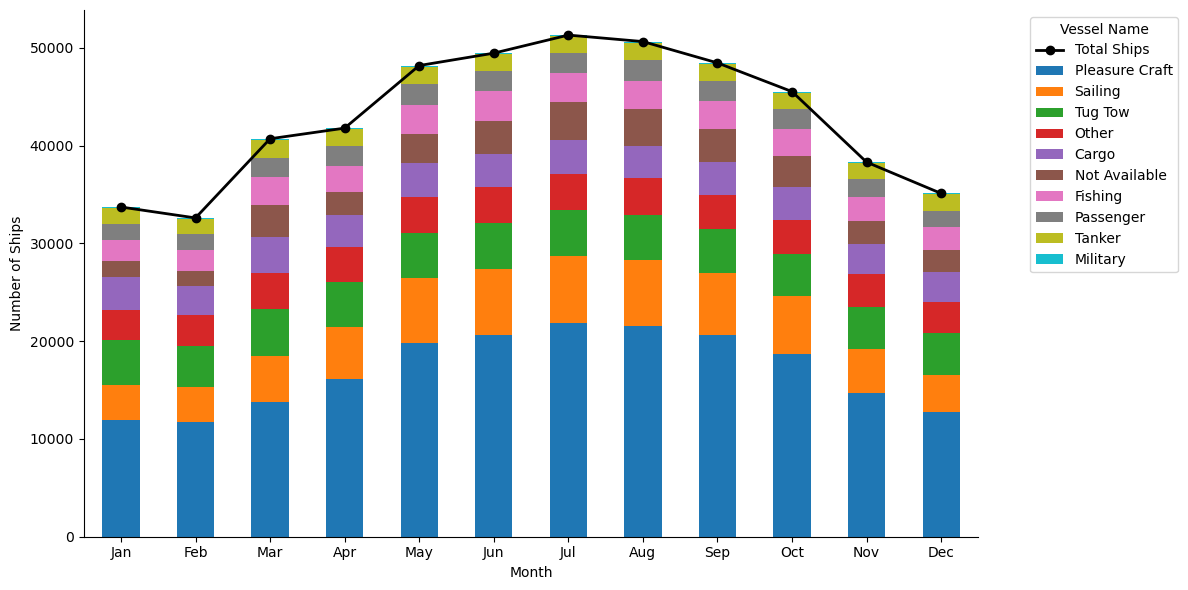

**Figure 2**. Monthly Vessel Distribution for the Year 2023

In [9]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Aggregate total ships per month and vessel
monthly_totals = (
    monthly_vessel_counts_df.groupby(["Month", "Vessel Name"])["NumShips"]
    .sum()
    .reset_index()
)

# Pivot the data
monthly_pivot = monthly_totals.pivot(
    index="Month", columns="Vessel Name", values="NumShips"
).fillna(0)

# Order columns by overall total (largest to smallest)
vessel_order = monthly_pivot.sum().sort_values(ascending=False).index
monthly_pivot = monthly_pivot[vessel_order]

# Stacked bar chart
monthly_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

# Compute x positions for the line (center of bars)
x = np.arange(len(monthly_pivot))

# Overlay line plot (total ships per month)
ax.plot(
    x, 
    monthly_pivot.sum(axis=1), 
    marker="o", 
    color="black", 
    linewidth=2, 
    label="Total Ships"
)

# Fix x-axis labels
ax.set_xticks(x)
month_labels = monthly_pivot.index.strftime("%b")
ax.set_xticklabels(month_labels, rotation=0)

# Titles and labels
ax.set_ylabel("Number of Ships")

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Vessel Name", bbox_to_anchor=(1.05, 1), loc="upper left")

# Remove top and right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 2**. Monthly Vessel Distribution for the Year 2023"))


In [10]:
# Convert counts to proportions per month
monthly_proportions = monthly_pivot.div(monthly_pivot.sum(axis=1), axis=0)

# Compute average proportion per vessel type across all months
average_proportions = monthly_proportions.mean().reset_index()
average_proportions.columns = ['Vessel Name', 'Average Proportion (%)']
average_proportions['Average Proportion (%)'] = (average_proportions['Average Proportion (%)'] * 100).round(2)

display(average_proportions)
display(Markdown("**Table 4**. Monthly Vessel Proportions for the Year 2023"))

,Vessel Name,Average Proportion (%)
0,Pleasure Craft,39.19
1,Sailing,12.39
2,Tug Tow,10.69
3,Other,8.27
4,Cargo,7.85
5,Not Available,6.48
6,Fishing,6.26
7,Passenger,4.60
8,Tanker,4.01
9,Military,0.25


**Table 4**. Monthly Vessel Proportions for the Year 2023

From the analysis of monthly vessel traffic, the focus was then shifted to a more granular hourly resolution to provide insights into temporal patterns of maritime activity. This finer analysis is particularly useful for operational planning, such as determining optimal staffing hours for harbor security or monitoring personnel. Figure 3 presents vessel activity aggregated by hour and by day, revealing that, unlike the pronounced monthly peaks, hourly traffic remains relatively consistent throughout the day. 

In [11]:
hourly_vessel_counts = (
    # truncate timestamp to the hour
    logs_with_vessel.withColumn("Hour", F.date_trunc("hour", "BaseDateTime"))
    # remove repeated logs for the same ship in the same hour
    .dropDuplicates(["MMSI", "Hour"])
    # group by vessel type and hour
    .groupBy("VesselType", "Hour")
    # count unique ships per group
    .agg(F.count("MMSI").alias("NumShips"))
    # order by time and vessel
    .orderBy("Hour", "VesselType")
)

parquet_path = "data/hourlies_cargo_counts.parquet"

if not os.path.exists(parquet_path):
    # Only save if the file doesn't exist
    hourly_vessel_counts.write.mode("overwrite").parquet(parquet_path)

hourly_cargo_counts_df = spark.read.parquet(parquet_path).toPandas()
hourly_cargo_counts_df["Hour"] = hourly_cargo_counts_df["Hour"].dt.hour
hourly_cargo_counts_df["Vessel Name"] = hourly_cargo_counts_df["VesselType"].map(
    ais_to_group
)

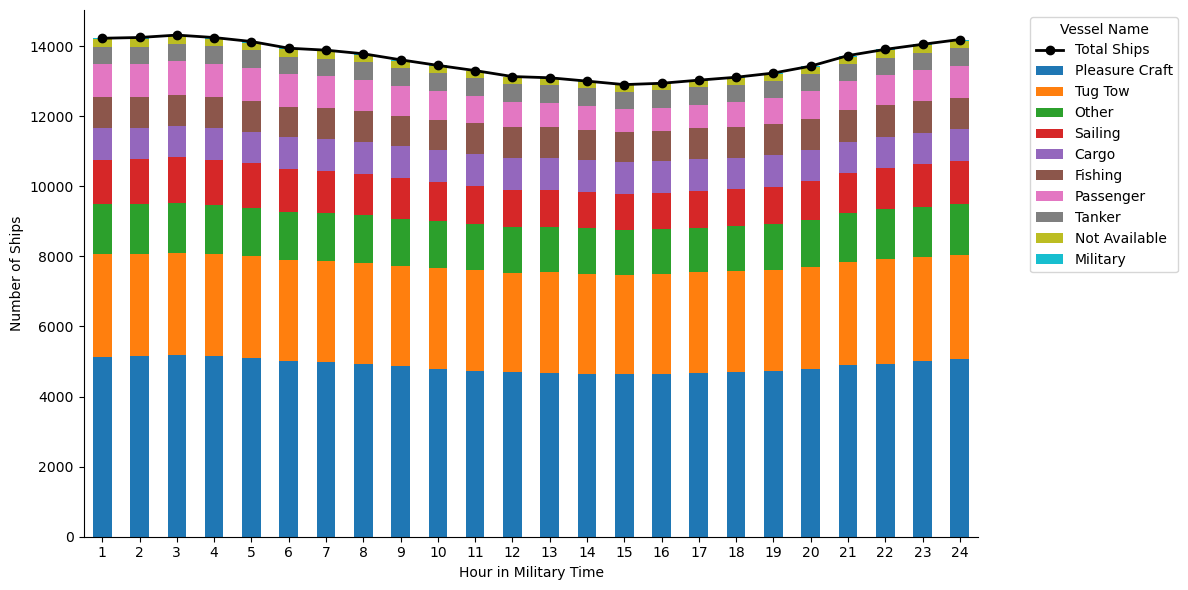

**Figure 3**. Hourly Vessel Distribution for the Year 2023

In [12]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Aggregate hourly totals and compute daily average
hourly_average = (
    hourly_cargo_counts_df.groupby(['Hour', 'Vessel Name'])['NumShips']
    .sum()
    .reset_index()
)
hourly_average['NumShips'] = hourly_average['NumShips'] / 365

# Pivot the data
hourly_pivot = hourly_average.pivot(
    index="Hour", columns="Vessel Name", values="NumShips"
).fillna(0)

# Order vessel types by overall total (largest to smallest)
vessel_order = hourly_pivot.sum().sort_values(ascending=False).index
hourly_pivot = hourly_pivot[vessel_order]

# Stacked bar chart (hourly)
hourly_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

# Compute x positions for the line (center of bars)
x = np.arange(len(hourly_pivot))

# Overlay line plot (total ships per hour)
ax.plot(
    x,
    hourly_pivot.sum(axis=1),
    marker="o",
    color="black",
    linewidth=2,
    label="Total Ships"
)

# Fix x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(x+1, rotation=0)

# Titles and labels
ax.set_ylabel("Number of Ships")
ax.set_xlabel("Hour in Military Time")

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Vessel Name", bbox_to_anchor=(1.05, 1), loc="upper left")

# Remove top and right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

display(Markdown("**Figure 3**. Hourly Vessel Distribution for the Year 2023"))


<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">VI. Investigate how ship speeds vary under different traffic densities</h1>

To determine the traffic density, the number of nearby ships were identified using a bounding box approach. This means that  for each vessel at a given timestamp, a rectangular area was defined around its latitude and longitude using a fixed spatial range of ±0.05 degrees in both latitude and longitude. All other vessels falling within this box during the same minute were considered “nearby.” This simple method provides an efficient approximation of vessel proximity without requiring computationally expensive calculations, such as Haversine distance or other geospatial metrics.

To handle the large volume of data, the logs were stratified by hour, and a small fraction of records per hour was sampled before computing nearby ship counts. This ensured that vessel activity across all times of day was represented fairly while keeping computations tractable. After identifying nearby ships per minute, the results were joined back to the sampled logs to include vessels with zero neighbors.

From Figure 4, the majority of ships clump at the beginning.

In [12]:
parquet_dir = "/mnt/data/public/noaa-ais/"

# List all 2023 Parquet files except the corrupted one
log_paths = sorted([
    os.path.join(parquet_dir, f)
    for f in os.listdir(parquet_dir)
    if f.startswith("2023_NOAA_AIS_logs_") and f != "2023_NOAA_AIS_logs_04.parquet"
])

def preprocess_logs_one_file(path):
    """
    Read one monthly log parquet and return:
    columns: MMSI, LAT, LON, SOG, BaseDateTime, Minute, Hour
    """
    df = spark.read.parquet(path)

    # Convert BaseDateTime from ns → proper timestamp
    df = df.withColumn(
        "BaseDateTime",
        F.to_timestamp(
            (F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long")
        )
    )

    # Add time granularity: Minute + Hour
    df = (
        df
        .withColumn("Minute", F.date_trunc("minute", F.col("BaseDateTime")))
        .withColumn("Hour", F.hour("BaseDateTime"))
        .select("MMSI", "LAT", "LON", "SOG", "BaseDateTime", "Minute", "Hour")
    )

    return df

def compute_nearby_ships_one_month(path, frac_per_hour=0.02, box_size=0.05, seed=42):
    """
    For a single monthly log file:
      1) preprocess
      2) stratified sample per hour
      3) compute number of nearby ships per MMSI per Minute using bounding box

    Returns a DataFrame with columns:
      MMSI, Minute, SOG, num_nearby_ships
    """
    #print(f"\n=== Processing file: {os.path.basename(path)} ===")

    # Step 1: preprocess this file
    df = preprocess_logs_one_file(path)

    # Step 2: stratified sample per Hour
    hours = [row["Hour"] for row in df.select("Hour").distinct().collect()]
    fractions = {h: frac_per_hour for h in hours}  # same fraction for each hour
    sampled = df.stat.sampleBy("Hour", fractions, seed=seed).cache()
    print("Sampled rows in this month:", sampled.count())

    # Step 3: self-join to get nearby ships at each Minute
    a = sampled.alias("a")
    b = sampled.alias("b")

    cond = (
        (F.col("a.Minute") == F.col("b.Minute"))       # same minute
        & (F.col("a.MMSI") != F.col("b.MMSI"))       # different ship
        & (F.col("b.LAT").between(F.col("a.LAT") - box_size,
                                  F.col("a.LAT") + box_size))
        & (F.col("b.LON").between(F.col("a.LON") - box_size,
                                  F.col("a.LON") + box_size))
    )

    nearby_pairs = a.join(b, cond, how="inner").select(
        F.col("a.MMSI").alias("MMSI"),
        F.col("a.Minute").alias("Minute"),
        F.col("a.SOG").alias("SOG"),
        F.col("b.MMSI").alias("other_MMSI"),
    )

    # Count number of nearby ships per MMSI per Minute
    nearby_count = (
        nearby_pairs
        .groupBy("MMSI", "Minute")
        .agg(F.countDistinct("other_MMSI").alias("num_nearby_ships"))
    )

    # Join back to sampled logs to include ships with zero neighbors
    result = (
        sampled.join(nearby_count, on=["MMSI", "Minute"], how="left")
        .fillna({"num_nearby_ships": 0})
        .select("MMSI", "Minute", "SOG", "num_nearby_ships")
    )

    return result

In [61]:
july_path = os.path.join(parquet_dir, "2023_NOAA_AIS_logs_07.parquet")

july_df = preprocess_logs_one_file(july_path)


In [14]:
spark.stop()
spark = SparkSession.builder \
    .appName("AIS_July") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

In [9]:
parquet_dir = "/mnt/data/public/noaa-ais/"
july_path = os.path.join(parquet_dir, "2023_NOAA_AIS_logs_07.parquet")
output_dir = "data/nearby_ships_july_partitioned"

# --- Preprocessing function ---
def preprocess_logs_one_file(path):
    df = spark.read.parquet(path)
    df = df.withColumn(
        "BaseDateTime",
        F.to_timestamp((F.col("BaseDateTime").cast("double") / 1_000_000_000).cast("long"))
    )
    df = df.withColumn("Minute", F.date_trunc("minute", F.col("BaseDateTime")))
    df = df.withColumn("Hour", F.hour("BaseDateTime"))
    df = df.withColumn("Day", F.dayofmonth("BaseDateTime"))  # add day column for partitioning
    return df.select("MMSI", "LAT", "LON", "SOG", "BaseDateTime", "Minute", "Hour", "Day")

# --- Nearby ships computation for a DataFrame chunk ---
def compute_nearby_ships(df_chunk, box_size=0.05):
    """
    df_chunk: Spark DataFrame (already filtered per day/hour)
    """
    a = df_chunk.alias("a")
    b = df_chunk.alias("b")

    cond = (
        (F.col("a.Minute") == F.col("b.Minute")) &
        (F.col("a.MMSI") != F.col("b.MMSI")) &
        (F.col("b.LAT").between(F.col("a.LAT") - box_size, F.col("a.LAT") + box_size)) &
        (F.col("b.LON").between(F.col("a.LON") - box_size, F.col("a.LON") + box_size))
    )

    nearby_pairs = a.join(b, cond, how="inner").select(
        F.col("a.MMSI").alias("MMSI"),
        F.col("a.Minute").alias("Minute"),
        F.col("a.SOG").alias("SOG"),
        F.col("b.MMSI").alias("other_MMSI"),
    )

    nearby_count = (
        nearby_pairs
        .groupBy("MMSI", "Minute")
        .agg(F.countDistinct("other_MMSI").alias("num_nearby_ships"))
    )

    result = (
        df_chunk.join(nearby_count, on=["MMSI", "Minute"], how="left")
        .fillna({"num_nearby_ships": 0})
        .select("MMSI", "Minute", "SOG", "num_nearby_ships", "Day")
    )
    return result

# --- Check if July output exists ---
if os.path.exists(output_dir) and os.listdir(output_dir):
    # Already exists → read full July DataFrame
    nearby_july_full = spark.read.parquet(output_dir)
    print("Full July nearby ships DataFrame loaded from existing partitions")
else:
    # Process July by day
    july_df = preprocess_logs_one_file(july_path)
    days = [row["Day"] for row in july_df.select("Day").distinct().collect()]

    for day in days:
        print(f"Processing Day {day}...")
        df_day = july_df.filter(F.col("Day") == day)
        nearby_day = compute_nearby_ships(df_day)

        # Save partitioned by day
        day_output = os.path.join(output_dir, f"day={day}")
        nearby_day.write.mode("overwrite").parquet(day_output)
        print(f"Saved Day {day} results to {day_output}")

    # Load full July DataFrame after processing
    all_days_paths = [os.path.join(output_dir, f"day={day}") for day in days]
    nearby_july_full = spark.read.parquet(*all_days_paths)
    print("Full July nearby ships DataFrame loaded from newly created partitions")



Full July nearby ships DataFrame loaded from existing partitions


In [11]:
june_path = os.path.join(parquet_dir, "2023_NOAA_AIS_logs_06.parquet")
output_dir = "data/nearby_ships_june_partitioned"

# --- Check if June output exists ---
if os.path.exists(output_dir) and os.listdir(output_dir):
    # Already exists → read full June DataFrame
    nearby_june_full = spark.read.parquet(output_dir)
    print("Full June nearby ships DataFrame loaded from existing partitions")
else:
    # Process June by day
    june_df = preprocess_logs_one_file(june_path)
    days = [row["Day"] for row in june_df.select("Day").distinct().collect()]

    for day in days:
        print(f"Processing Day {day}...")
        df_day = june_df.filter(F.col("Day") == day)
        nearby_day = compute_nearby_ships(df_day)

        # Save partitioned by day
        day_output = os.path.join(output_dir, f"day={day}")
        nearby_day.write.mode("overwrite").parquet(day_output)
        print(f"Saved Day {day} results to {day_output}")

    # Load full June DataFrame after processing
    all_days_paths = [os.path.join(output_dir, f"day={day}") for day in days]
    nearby_june_full = spark.read.parquet(*all_days_paths)
    print("Full June nearby ships DataFrame loaded from newly created partitions")


Processing Day 1...
Saved Day 1 results to data/nearby_ships_june_partitioned/day=1
Processing Day 2...
Saved Day 2 results to data/nearby_ships_june_partitioned/day=2
Processing Day 3...
Saved Day 3 results to data/nearby_ships_june_partitioned/day=3
Processing Day 4...
Saved Day 4 results to data/nearby_ships_june_partitioned/day=4
Processing Day 5...
Saved Day 5 results to data/nearby_ships_june_partitioned/day=5
Processing Day 6...
Saved Day 6 results to data/nearby_ships_june_partitioned/day=6
Processing Day 7...
Saved Day 7 results to data/nearby_ships_june_partitioned/day=7
Processing Day 8...
Saved Day 8 results to data/nearby_ships_june_partitioned/day=8
Processing Day 9...
Saved Day 9 results to data/nearby_ships_june_partitioned/day=9
Processing Day 10...
Saved Day 10 results to data/nearby_ships_june_partitioned/day=10
Processing Day 11...
Saved Day 11 results to data/nearby_ships_june_partitioned/day=11
Processing Day 12...
Saved Day 12 results to data/nearby_ships_june_pa

In [27]:
august_path = os.path.join(parquet_dir, "2023_NOAA_AIS_logs_08.parquet")
output_dir = "data/nearby_ships_august_partitioned"

# --- Check if August output exists ---
if os.path.exists(output_dir) and os.listdir(output_dir):
    # Already exists → read full August DataFrame
    nearby_august_full = spark.read.parquet(output_dir)
    print("Full August nearby ships DataFrame loaded from existing partitions")
else:
    # Process August by day
    august_df = preprocess_logs_one_file(august_path)
    days = [row["Day"] for row in august_df.select("Day").distinct().collect()]

    for day in days:
        print(f"Processing Day {day}...")
        df_day = august_df.filter(F.col("Day") == day)
        nearby_day = compute_nearby_ships(df_day)

        # Save partitioned by day
        day_output = os.path.join(output_dir, f"day={day}")
        nearby_day.write.mode("overwrite").parquet(day_output)
        print(f"Saved Day {day} results to {day_output}")

    # Load full August DataFrame after processing
    all_days_paths = [os.path.join(output_dir, f"day={day}") for day in days]
    nearby_august_full = spark.read.parquet(*all_days_paths)
    print("Full August nearby ships DataFrame loaded from newly created partitions")


Full August nearby ships DataFrame loaded from existing partitions


In [13]:
#spark.stop()
spark = SparkSession.builder \
    .appName("AIS_July") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")

paths = [
    "data/nearby_ships_june_partitioned",
    "data/nearby_ships_july_partitioned",
    "data/nearby_ships_august_partitioned",
]

# Load and union
dfs = [spark.read.parquet(p) for p in paths]
df = reduce(lambda a, b: a.unionByName(b), dfs)

# Filter invalid speed values
df = df.filter(F.col("SOG").isNotNull() & (F.col("SOG") >= 0))

# Compute table
sog_stats = (
    df.groupBy("num_nearby_ships")
      .agg(F.mean("SOG").alias("Mean_SOG"))
      .orderBy("num_nearby_ships")
)

# Convert to Pandas DataFrame for proper tabular display
sog_df = sog_stats.toPandas()

# Display as a DataFrame (Jupyter will render this as a table)
sog_df

,num_nearby_ships,Mean_SOG
0,0,6.905084
1,1,3.817936
2,2,2.982453
3,3,2.567686
4,4,2.260402
...,...,...
158,158,4.455556
159,159,4.425000
160,160,3.425000
161,162,10.400000


In [14]:
df.filter(F.col("num_nearby_ships").isNotNull() & (F.col("num_nearby_ships") >= 150)).show()

+---------+-------------------+----+----------------+---+
|     MMSI|             Minute| SOG|num_nearby_ships|day|
+---------+-------------------+----+----------------+---+
|311001124|2023-06-20 22:03:00| 9.1|             151| 20|
|319194000|2023-06-20 22:03:00| 0.0|             151| 20|
|319489000|2023-06-20 20:10:00| 0.0|             150| 20|
|338841095|2023-06-20 00:03:00|38.6|             153| 20|
|351578000|2023-06-20 00:18:00| 8.8|             158| 20|
|366804450|2023-06-20 02:01:00| 0.0|             151| 20|
|366804450|2023-06-20 19:01:00| 7.7|             157| 20|
|366804450|2023-06-20 19:03:00| 7.5|             156| 20|
|366832740|2023-06-20 02:12:00|10.4|             150| 20|
|366874920|2023-06-20 20:01:00| 0.0|             151| 20|
|366935050|2023-06-20 20:25:00| 1.5|             151| 20|
|366941860|2023-06-20 01:46:00| 8.3|             151| 20|
|366952340|2023-06-20 00:47:00| 7.3|             152| 20|
|366959090|2023-06-20 19:02:00| 0.3|             150| 20|
|366959090|202

In [15]:
ships_df.filter(F.col("MMSI").isNotNull() & (F.col("MMSI") == 338457389)).show()

+---------+-----------+----------+---------+----------+------+------+-----+-----+-----+----------------+-------------------+
|     MMSI| VesselName|       IMO| CallSign|VesselType|Status|Length|Width|Draft|Cargo|TransceiverClass|       BaseDateTime|
+---------+-----------+----------+---------+----------+------+------+-----+-----+-----+----------------+-------------------+
|338457389|SAN JACINTO|IMO0000000|<Unknown>|      50.0|  NULL|  15.0|  8.0| NULL| NULL|               B|1688308277000000000|
|338457389|SAN JACINTO|IMO0000000|<Unknown>|      50.0|  NULL|  15.0|  8.0| NULL| NULL|               B|1691150870000000000|
|338457389|SAN JACINTO|IMO0000000|<Unknown>|      50.0|  NULL|  15.0|  8.0| NULL| NULL|               B|1685644912000000000|
|338457389|SAN JACINTO|IMO0000000|<Unknown>|      50.0|  NULL|  15.0|  8.0| NULL| NULL|               B|1682899226000000000|
|338457389|SAN JACINTO|IMO0000000|<Unknown>|      50.0|  NULL|  15.0|  8.0| NULL| NULL|               B|1693674177000000000|


In [16]:
joined = (
    df
    .filter(F.col("num_nearby_ships").isNotNull() & (F.col("num_nearby_ships") >= 150))
    .join(
        ships_df.filter(F.col("MMSI").isNotNull()),
        on="MMSI",
        how="inner"
    )
)

# PUT INTO PARQUET FILE

In [17]:
# put into a parquet file 
df = joined.toPandas()

In [18]:
# df.to_csv("nearby_outliers.csv", index=False)
df.to_parquet("nearby_outliers.parquet", index=False)

In [19]:
df['VesselType'].map(ais_to_group).value_counts(normalize=True)

VesselType
Tug Tow    0.782214
Other      0.192377
Tanker     0.021779
Cargo      0.003630
Name: proportion, dtype: float64

In [20]:
df['VesselType'].value_counts()

VesselType
31.0    2361
57.0     516
52.0     189
90.0      84
80.0      36
32.0      36
82.0      31
23.0      24
70.0      12
55.0      12
89.0       5
Name: count, dtype: int64

In [24]:
# ship_counts = ( 
#     df.groupby("num_nearby_ships")
#     .agg(F.count("*").alias("ship_count"))
#     .orderBy("num_nearby_ships") 
# ) # Convert to Pandas DataFrame for tabular display 

# ship_counts_df = ship_counts.toPandas() 
# ship_counts_df

# df is already Pandas, so just group normally
ship_counts_df = (
    df.groupby("num_nearby_ships")
      .size()
      .reset_index(name="ship_count")
      .sort_values("num_nearby_ships")
)

ship_counts_df

,num_nearby_ships,ship_count
0,150,930
1,151,662
2,152,515
3,153,433
4,154,281
5,155,73
6,156,96
7,157,108
8,158,102
9,159,44


In [25]:
ship_counts_df[ship_counts_df['ship_count'] > ship_counts_df['num_nearby_ships']]

,num_nearby_ships,ship_count
0,150,930
1,151,662
2,152,515
3,153,433
4,154,281


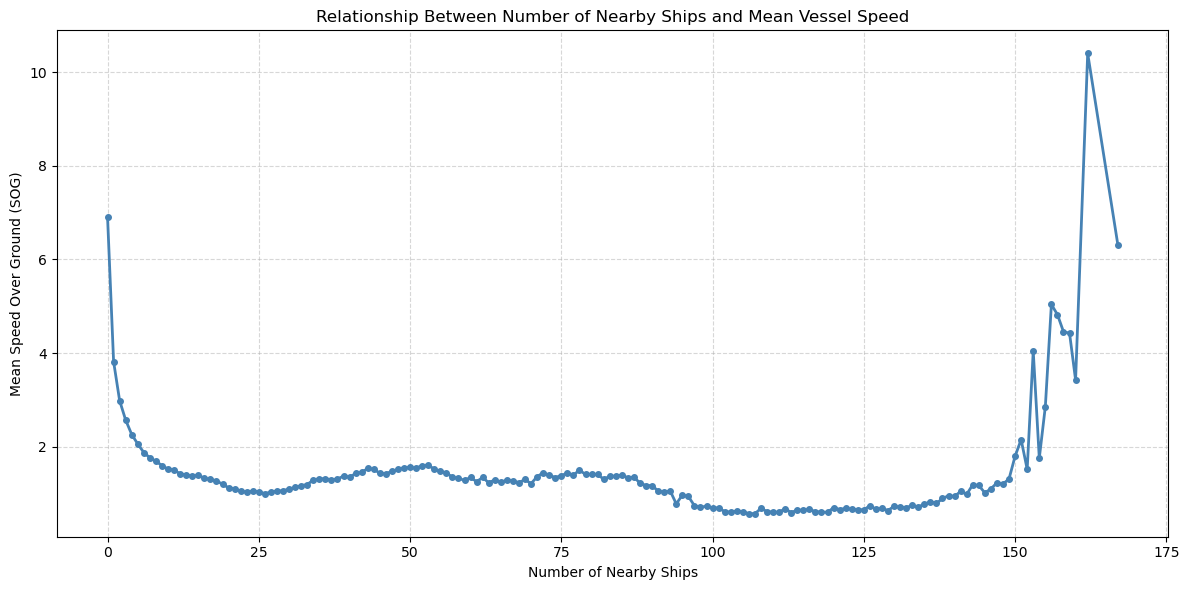

In [26]:
sog_df = sog_df.sort_values("num_nearby_ships")

plt.figure(figsize=(12, 6))
plt.plot(
    sog_df["num_nearby_ships"],
    sog_df["Mean_SOG"],
    marker="o",
    linestyle="-",
    linewidth=2,
    markersize=4,
    color="steelblue"
)

plt.xlabel("Number of Nearby Ships")
plt.ylabel("Mean Speed Over Ground (SOG)")
plt.title("Relationship Between Number of Nearby Ships and Mean Vessel Speed")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

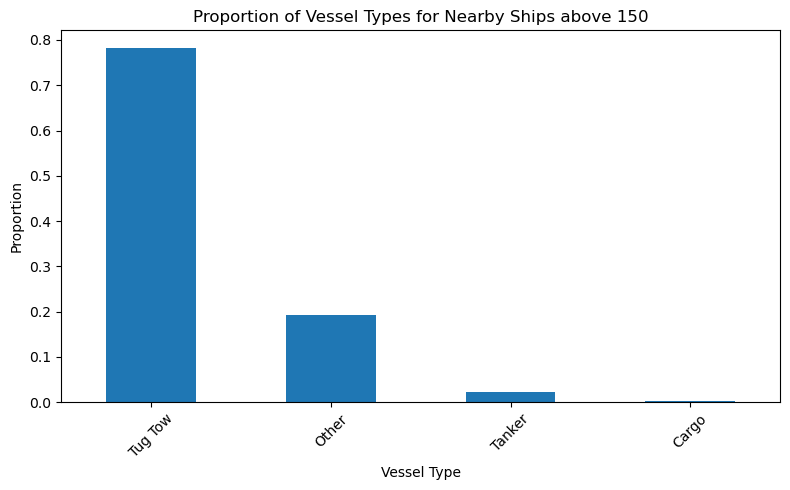

In [31]:
vessel_counts = df['VesselType'].map(ais_to_group).value_counts(normalize=True)

plt.figure(figsize=(8,5))
vessel_counts.plot(kind='bar')

plt.title("Proportion of Vessel Types for Nearby Ships above 150")
plt.xlabel("Vessel Type")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<a id='Apply FIM'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">VII. Analyze and Interpret the Results</h1>

In [27]:
# Compute monthly totals per vessel
monthly_totals = (
    monthly_vessel_counts_df.groupby(["Month", "Vessel Name"])["NumShips"]
    .sum()
    .reset_index()
)

# Compute total ships per month
month_totals = monthly_totals.groupby("Month")["NumShips"].transform("sum")

# Compute percentage per vessel per month
monthly_totals["Percentage"] = monthly_totals["NumShips"] / month_totals * 100

# Pivot: rows = Vessel Name, columns = Month, values = Percentage
monthly_percentage = monthly_totals.pivot(
    index="Vessel Name", columns="Month", values="Percentage"
).fillna(
    0
)  # fill NaN with 0 if a vessel didn't appear in a month

# Compute cosine similarity between consecutive months
months = monthly_percentage.columns.tolist()
cosine_similarities = {}

for i in range(len(months)):
    month1 = months[i]
    month2 = months[(i + 1) % len(months)]  # wrap around 12 -> 1
    vec1 = monthly_percentage[month1].values.reshape(1, -1)
    vec2 = monthly_percentage[month2].values.reshape(1, -1)

    sim = cosine_similarity(vec1, vec2)[0][0]
    cosine_similarities[f"{month1}->{month2}"] = sim

# Convert results to a DataFrame for easier viewing
cosine_sim_df = pd.DataFrame(
    list(cosine_similarities.items()), columns=["Month Pair", "Cosine Similarity"]
)

cosine_sim_df

,Month Pair,Cosine Similarity
0,2023-01-01 00:00:00->2023-02-01 00:00:00,0.999578
1,2023-02-01 00:00:00->2023-03-01 00:00:00,0.995649
2,2023-03-01 00:00:00->2023-04-01 00:00:00,0.993989
3,2023-04-01 00:00:00->2023-05-01 00:00:00,0.998044
4,2023-05-01 00:00:00->2023-06-01 00:00:00,0.999814
5,2023-06-01 00:00:00->2023-07-01 00:00:00,0.999672
6,2023-07-01 00:00:00->2023-08-01 00:00:00,0.999973
7,2023-08-01 00:00:00->2023-09-01 00:00:00,0.999930
8,2023-09-01 00:00:00->2023-10-01 00:00:00,0.999591
9,2023-10-01 00:00:00->2023-11-01 00:00:00,0.997601


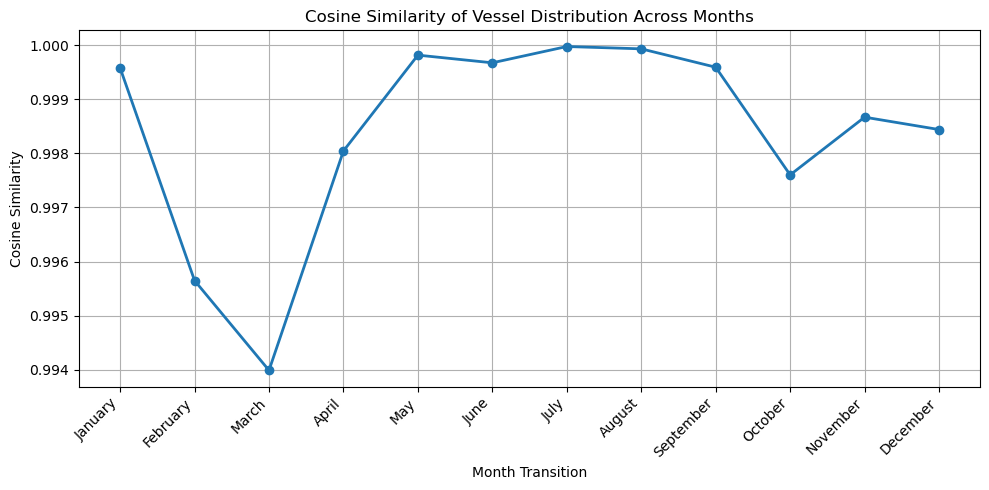

In [28]:
cosine_sim_df["MonthStart"] = pd.to_datetime(
    cosine_sim_df["Month Pair"].str.split("->").str[0]
)

# Sort in calendar order
cosine_sim_df = cosine_sim_df.sort_values("MonthStart")

# Create readable month labels (e.g., January, February, ...)
cosine_sim_df["Month Label"] = cosine_sim_df["MonthStart"].dt.strftime("%B")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(
    cosine_sim_df["Month Label"],
    cosine_sim_df["Cosine Similarity"],
    marker="o",
    linestyle="-",
    linewidth=2
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cosine Similarity")
plt.xlabel("Month Transition")
plt.title("Cosine Similarity of Vessel Distribution Across Months")
plt.grid(True)
plt.tight_layout()
plt.show()

<a id='Recommendation'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">VIII. RECOMMENDATION & LIMITATIONS</h1>

<a id='Limitations'></a>
<h2 style="color:#ff9a00">A. Limitations of the Study</h2>

In this study, nearby ships were identified using a simple bounding box approach, which has a key limitation where it assumes that the same spatial distance applies uniformly across the globe. In this study specifically, ships were considered nearby if they fell within ±0.05 degrees in both latitude and longitude, which corresponds roughly to 5–6 km. This simplification ignores the fact that one degree of latitude or longitude represents different distances at different latitudes, and it may have introduced minor inaccuracies in identifying truly nearby vessels, particularly in regions where maritime traffic is dense or geographically constrained. 

While more precise methods, such as calculating the Haversine distance, were considered, they were ultimately deemed computationally expensive due to the trigonometric calculations involved. Specifically, functions like `haversine()` from the haversine Python package or `geopy.distance.distance()` could have provided greater accuracy, but at a significant cost in processing time given the large volume of vessel data. 


<a id='Recommendation2'></a>
<h2 style="color:#ff9a00">B. Recommendation</h2>

1. **Operational Recommendations:**

For US maritime officials, staffing levels should be adjusted to reflect seasonal variations in maritime traffic. Specifically, the results indicated that vessel traffic peaks during the summer months, so the number of officials or support staff during this period should be increased to improve monitoring and safety enforcement.

Second, pleasure vessels, which make up the majority of the observed traffic, should be further subdivided according to the purpose of their trips. Categories such as tourism, stress-relief, or recreation can provide greater insight into behavioral differences between vessel types. This subdivision could also inform policy decisions, resource allocation, and targeted safety interventions.

Third, staff coverage should be aligned with hourly traffic patterns. Since vessel counts were found to be relatively constant throughout the day, operational planning should not be limited to standard working hours. Extending coverage into off-peak hours would ensure continuous monitoring and enhance overall maritime safety.
    
2. **Technical and Research Recommendations:**

For future studies, the use of machine learning techniques could provide deeper insights into vessel behavior. By prediciting Speed Over Ground (SOG) based on features such as vessel type, latitude, and longitude, predictive models could help explain why certain vessels operate at higher or lower speeds under different conditions.

Given the dominance of pleasure vessels, future research could also explore behavioral patterns or identify key groups through clustering. For example, the latitude, longitude, and SOG could be used as features so that they could possibly reveal distinct subgroups within pleasure vessels. 

In conclusion, while this study provides an initial understanding of vessel traffic patterns, implementing the recommendations above could enhance both operational efficiency and the scientific understanding of maritime behavior, particularly among pleasure vessels which represent the largest share of maritime activity.

<a id='Conclusion'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">IX. CONCLUSION</h1>

The analysis of 2023 NOAA AIS data demonstrates a relationship between vessel type, traffic density, and vessel speed, providing a solution to the stated problem. Specifically, pleasure vessels constitute approximately 39% of all observed traffic, making them the dominant vessel type in U.S. waters, particularly during the summer months of June, July, and August. Other notable vessel types include sailing vessels at 12% and tug/tow vessels at 9%. Although there are significant differences betwen the months, hourly traffic is different since it remains relatively constant throughout the day. By computing the number of nearby ships using a bounding box approach (±0.05° in latitude and longitude, roughly 5–6 km), it was observed that most vessels travel at low speeds (X number), with higher speeds occurring primarily when there are few or no nearby vessels. These findings show that most vessels maintain low speeds even in dense traffic, with higher speeds occurring only when nearby vessel counts are low, highlighting limited but observable effects of local congestion on vessel behavior.

Consequently, operational strategies—such as increasing staff during peak summer months, extending coverage beyond standard working hours, and categorizing pleasure vessels by trip purpose (e.g., tourism, stress-relief, recreation)—can be directly informed by these patterns. Technically, predictive modeling using features such as vessel type, location, and speed, as well as clustering analyses, can further elucidate behavioral patterns among vessels.

In summary, the study provides actionable insights for maritime authorities to anticipate high-risk periods, optimize traffic management, and enhance safety. The solution to the stated problem is therefore to leverage vessel type, traffic density, and speed data—specifically the 39% prevalence of pleasure vessels and their observed speed patterns under varying densities—to inform both operational decisions and predictive modeling, thereby improving navigation safety and understanding vessel behavior in U.S. waters.

<a id='References'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">ACKNOWLEDGEMENTS</h1>

The team would like to acknowledge Food.com as the original source of the reviews and the Asian Institute of Management's "jojie-collected" repository for compiling and sharing the food-com-recipes dataset for public educational use. They would like to express their sincere appreciation to their learning team members and Professor Christian M. Alis for their invaluable guidance and support in completing this report. The group also acknowledges their use of Artificial Intelligence, such as ChatGPT. 


<a id='References'></a>
<h1 style="color:#ffffff; background-color:#0b88fb; border: 1px solid #ffffff; padding: 10px 0;">REFERENCES</h1>

***
**END**